In [1]:
import matplotlib.pyplot as plt

from utils.data import DataManager
from utils.tools import BENCHMARKS, RISK_ANALYSIS

from utils.analysis.capm import (
    CAPMAnalyzer,
    PortfolioOptimizationAnalyzer,
    MultiAssetCAPMAnalyzer,
    CAPMReporter,
    PortfolioReporter,
    MultiAssetReporter
)

from utils.visualizations import (
    CAPMVisualizer,
    PortfolioOptimizationVisualizer,
    MultiAssetCAPMVisualizer
)

In [ ]:
# Inicializar analyzers
capm_analyzer = CAPMAnalyzer(annual_factor=252)
portfolio_optimizer = PortfolioOptimizationAnalyzer(annual_factor=252)
multi_capm = MultiAssetCAPMAnalyzer(annual_factor=252)

# Inicializar reporters
capm_reporter = CAPMReporter(capm_analyzer)
portfolio_reporter = PortfolioReporter(portfolio_optimizer)
multi_asset_reporter = MultiAssetReporter(multi_capm)

# Inicializar visualizers
capm_viz = CAPMVisualizer(capm_analyzer)
portfolio_viz = PortfolioOptimizationVisualizer(portfolio_optimizer)
multi_asset_viz = MultiAssetCAPMVisualizer(multi_capm)

data_manager = DataManager()

In [3]:
TICKERS = ["META", "AAPL", "GOOGL", "MSFT", "NVDA"]
BENCHMARK_NAME = "SP500"
START_DATE = "2020-01-01"
END_DATE = "2024-12-31"

BENCHMARK_TICKER = BENCHMARKS[BENCHMARK_NAME]
RISK_FREE_RATE = RISK_ANALYSIS['risk_free_rate']
ANNUAL_FACTOR = RISK_ANALYSIS['annual_factor']

In [4]:
assets_prices, benchmark_prices = data_manager.download_portfolio_with_benchmark(
    tickers=TICKERS,
    benchmark_name=BENCHMARK_NAME,
    start_date=START_DATE,
    end_date=END_DATE
)

# Calcular retornos
returns = assets_prices.pct_change().dropna()
benchmark_returns = benchmark_prices.pct_change().dropna()

Descargando portafolio completo...
Período: 2020-01-01 → 2024-12-31


[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed


Período: 2020-01-01 → 2024-12-31
Portafolio descargado: 5 activos + benchmark


In [5]:
capm_reporter.generate_report(
    asset_returns=returns['META'].values,
    market_returns=benchmark_returns.values,
    risk_free_rate=RISK_FREE_RATE,
    asset_name="META"
)

                    ANÁLISIS CAPM: META                     
PARÁMETROS DEL MODELO
  Beta:                       1.308
  Correlación:                0.622
  R²:                         0.386
ALPHA (Jensen)
  Alpha Diario:              0.0549%
  Alpha Anual:                14.83%
SIGNIFICANCIA ESTADÍSTICA
  t-statistic:                0.885
  p-value:                   0.3762
  Significativo (α=0.05):  [NO]
[INFO] Alpha no significativo: el activo se comporta según lo esperado por CAPM


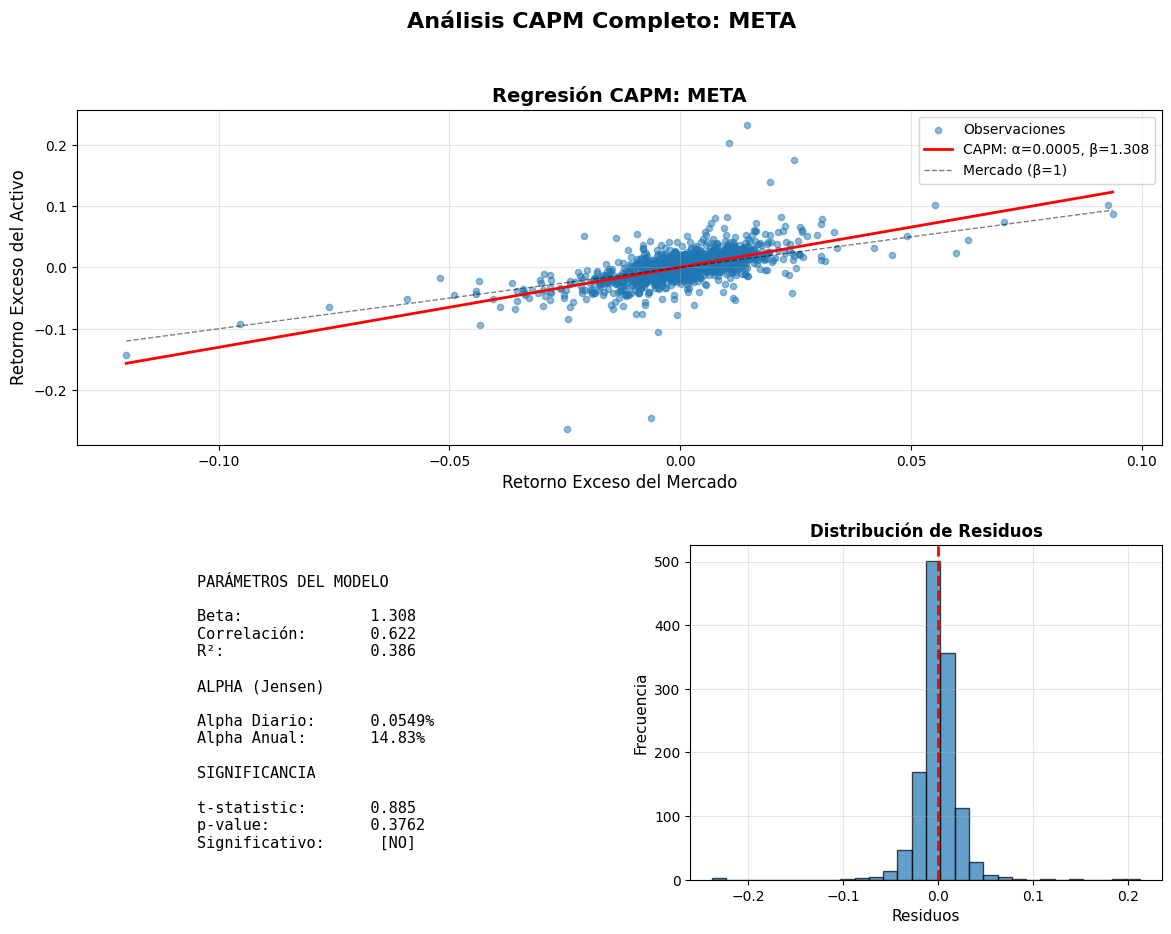

In [6]:
fig1 = capm_viz.plot_capm_analysis(
    asset_returns=returns['META'].values,
    market_returns=benchmark_returns.values,
    risk_free_rate=RISK_FREE_RATE,
    asset_name="META"
)
plt.show()

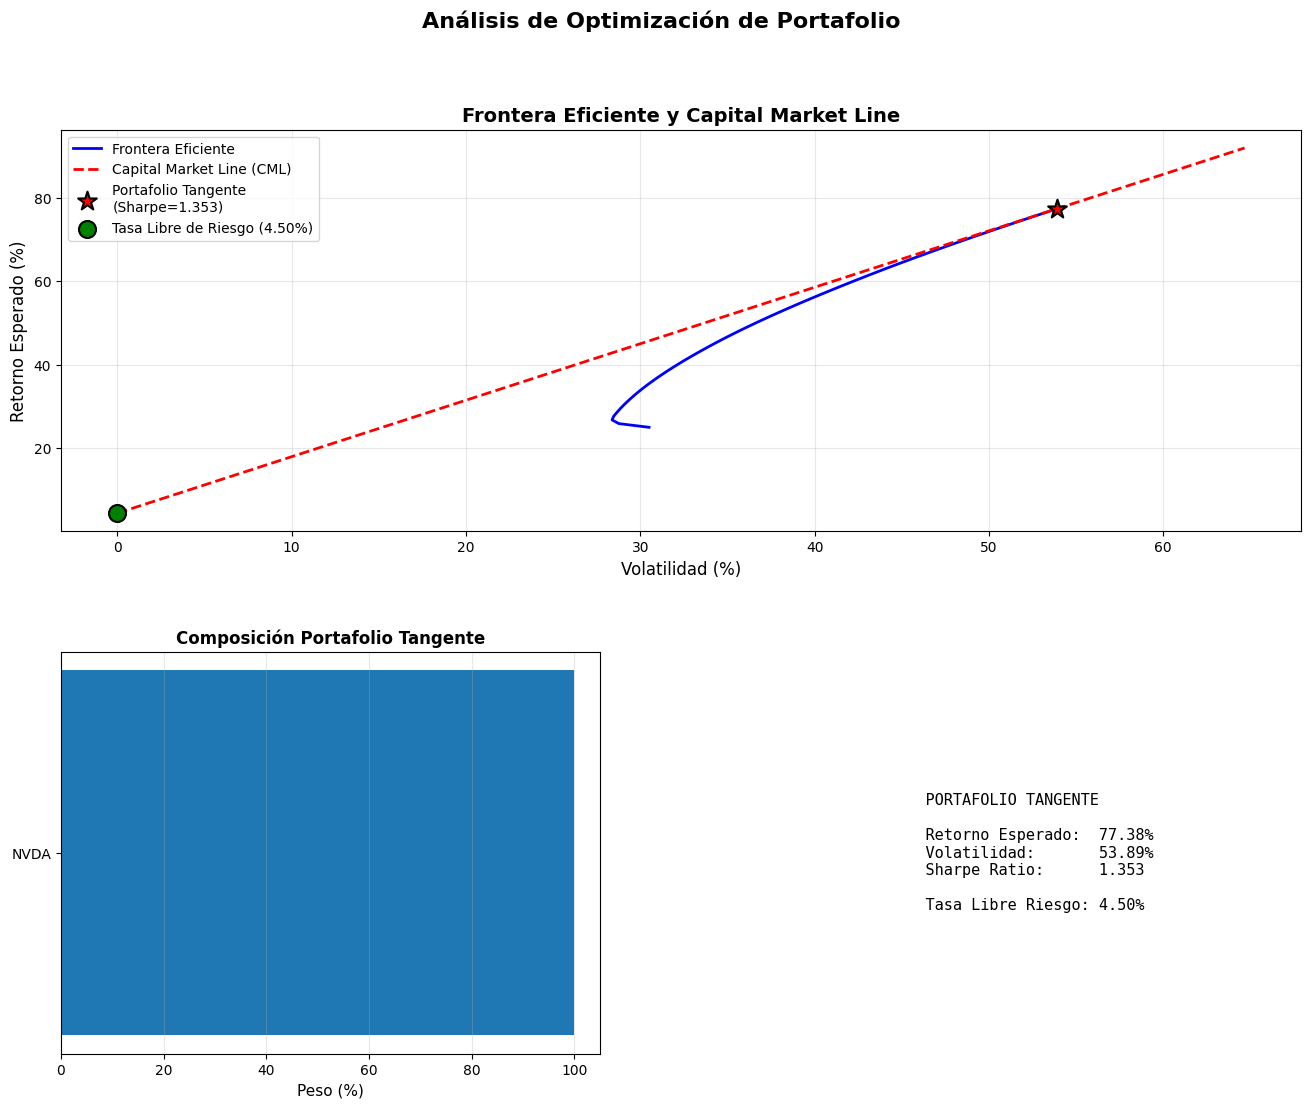

In [7]:
fig2 = portfolio_viz.plot_efficient_frontier_analysis(
    returns=returns,
    risk_free_rate=RISK_FREE_RATE
)
plt.show()


In [8]:
portfolio_reporter.generate_tangent_report(
    returns=returns,
    risk_free_rate=RISK_FREE_RATE
)


            PORTAFOLIO TANGENTE (Máximo Sharpe)             
CARACTERÍSTICAS
  Retorno Esperado:           77.38%
  Volatilidad:                53.89%
  Sharpe Ratio:               1.353
COMPOSICIÓN DEL PORTAFOLIO
  NVDA        100.00%


In [9]:
multi_asset_reporter.generate_summary_report(
    returns=returns,
    market_returns=benchmark_returns,
    risk_free_rate=RISK_FREE_RATE
)

                           ANÁLISIS CAPM MULTI-ACTIVO                           
Activos analizados: 5
ESTADÍSTICAS GENERALES
  Beta promedio:              1.309
  Alpha promedio (anual):     24.98%
  R² promedio:                0.545

[OK] Alphas significativos: 1 / 5
TOP 5 PERFORMERS (Alpha más alto)
  [OK] NVDA       Alpha:   74.45%  Beta:  1.757
       AAPL       Alpha:   15.05%  Beta:  1.173
       META       Alpha:   14.83%  Beta:  1.308
       GOOGL      Alpha:   11.01%  Beta:  1.133
       MSFT       Alpha:    9.56%  Beta:  1.174
BOTTOM 5 PERFORMERS (Alpha más bajo)
       MSFT       Alpha:    9.56%  Beta:  1.174
       GOOGL      Alpha:   11.01%  Beta:  1.133
       META       Alpha:   14.83%  Beta:  1.308
       AAPL       Alpha:   15.05%  Beta:  1.173
  [OK] NVDA       Alpha:   74.45%  Beta:  1.757
Nota: [OK] indica alpha estadísticamente significativo (p < 0.05)


In [10]:
capm_results = multi_capm.analyze_multiple(
    returns=returns,
    market_returns=benchmark_returns,
    risk_free_rate=RISK_FREE_RATE
)
display(capm_results)

,alpha_daily,alpha_annual,beta,correlation,r_squared,t_statistic,p_value,is_significant
asset,,,,,,,,
NVDA,0.002211,0.744528,1.757320,0.696157,0.484635,3.091371,0.002036,True
AAPL,0.000556,0.150464,1.173257,0.790363,0.624674,1.575123,0.115480,False
META,0.000549,0.148263,1.307967,0.621650,0.386449,0.885184,0.376227,False
GOOGL,0.000415,0.110129,1.132653,0.743790,0.553224,1.226042,0.220413,False
MSFT,0.000362,0.095563,1.174030,0.821534,0.674919,1.294793,0.195630,False


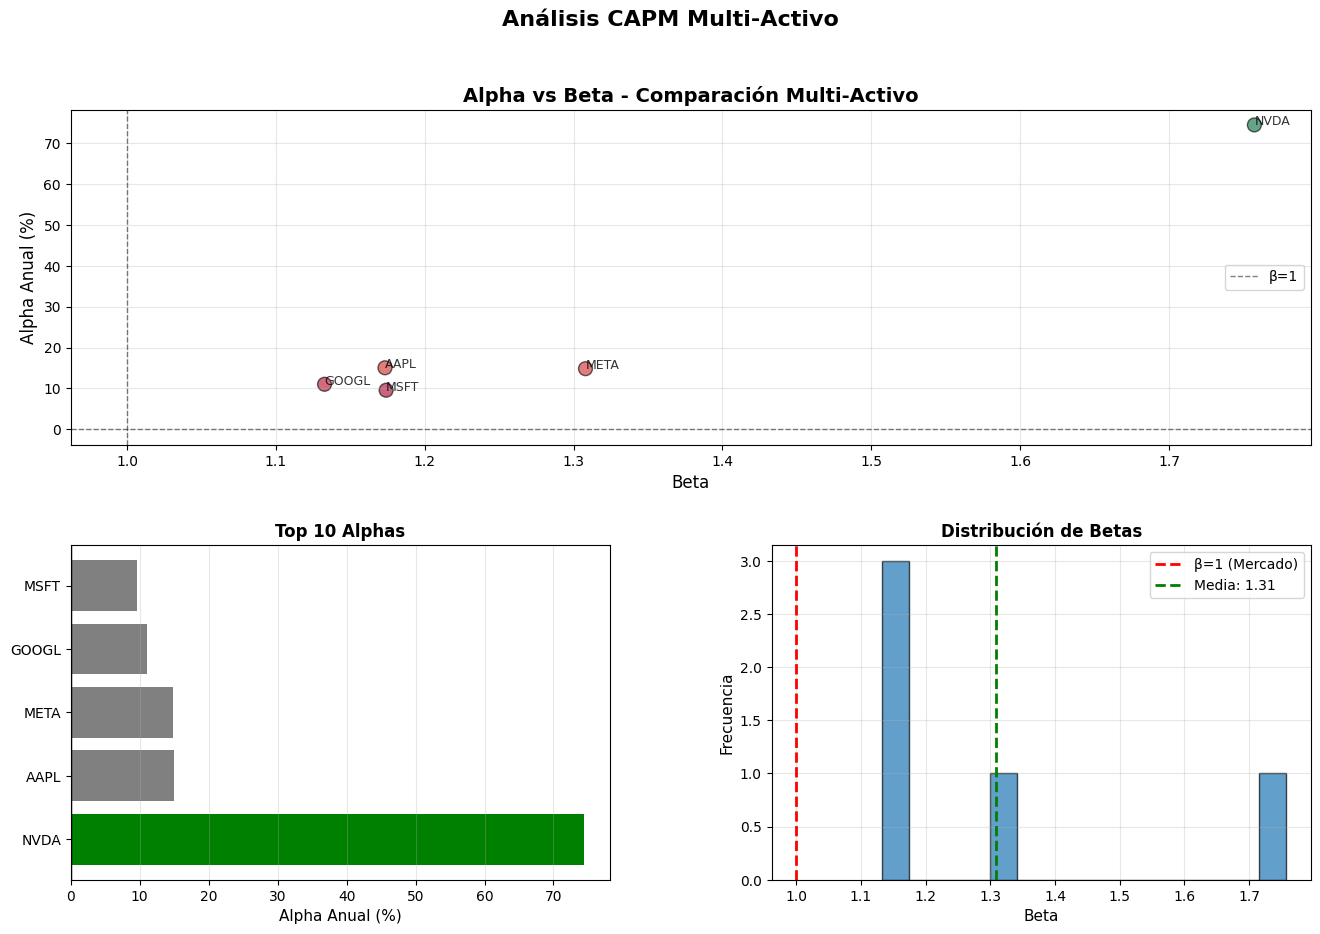

In [11]:
fig3 = multi_asset_viz.plot_multi_asset_analysis(
    returns=returns,
    market_returns=benchmark_returns,
    risk_free_rate=RISK_FREE_RATE
)
plt.show()